# **GAME SALES ANALYTICS**
### Análise das vendas de videogames com regressão linear

Neste trabalho buscamos entender quais informações da base têm relação com as vendas globais de um jogo. Para isso, usamos análise exploratória, regressão linear e regressão polinomial.

A ideia não é prever com certeza se um jogo será um sucesso. Queremos verificar o quanto os dados disponíveis conseguem explicar as vendas e observar onde o modelo mais erra.

**Alunos:** Gabriel Silveira e Marcos Reis  
**Dataset:** [Video Game Sales with Ratings](https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings)  
**Alvo:** Global_Sales, em milhões de unidades.

## 1) Business Understanding

### Objetivo

A pergunta principal é: quais características dos jogos ajudam a explicar suas vendas globais?

O resultado pode ajudar na comparação entre jogos, gêneros e plataformas. Como algumas informações só existem depois do lançamento, o modelo será usado para análise, e não como uma previsão antecipada de sucesso.

### Avaliação

O RMSE será a métrica principal. Também vamos observar MAE e R². Os modelos serão comparados com validação cruzada e o teste será usado somente no final.

## 2) Data Understanding

Nesta etapa conhecemos a base e procuramos problemas que podem afetar a análise.

In [1]:
# Manipulação e visualização dos dados
import json
import warnings
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from kagglehub import KaggleDatasetAdapter

# Preparação, modelagem e validação
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

SEMENTE = 42
ALVO = "Global_Sales"

C:\Users\gabri\Desktop\games-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Carregamento reproduzível

O arquivo é obtido pelo KaggleHub. A leitura explicita a codificação porque o conjunto contém caracteres incompatíveis com UTF-8 em algumas linhas. Nenhuma linha é descartada silenciosamente.

In [2]:
caminho_arquivo = "Video_Games_Sales_as_at_22_Dec_2016.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rush4ratio/video-game-sales-with-ratings",
    caminho_arquivo,
    pandas_kwargs={"encoding": "cp1252", "encoding_errors": "replace"},
)

print(f"Dimensão da base: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
display(df.head(3))

Dimensão da base: 16,719 linhas × 16 colunas


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,"2,006.000",Sports,Nintendo,41.360,28.960,3.770,8.450,82.530,76.000,51.000,8,322.000,Nintendo,E
1,Super Mario Bros.,NES,"1,985.000",Platform,Nintendo,29.080,3.580,6.810,0.770,40.240,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.000",Racing,Nintendo,15.680,12.760,3.790,3.290,35.520,82.000,73.000,8.3,709.000,Nintendo,E


### 2.3 Visão geral da base

Verificamos o tamanho da base, os tipos das colunas, valores ausentes, duplicatas e estatísticas básicas.

In [3]:
def resumir_estrutura(dados):
    # Retorna tipo, preenchimento e cardinalidade de cada coluna.
    return pd.DataFrame({
        "tipo": dados.dtypes.astype(str),
        "não_nulos": dados.notna().sum(),
        "ausentes": dados.isna().sum(),
        "ausentes_%": dados.isna().mean().mul(100).round(2),
        "valores_únicos": dados.nunique(dropna=True),
    })


estrutura = resumir_estrutura(df)
display(estrutura)
print(f"Duplicatas exatas: {df.duplicated().sum():,}")
display(df.describe(include="number").T)

,tipo,não_nulos,ausentes,ausentes_%,valores_únicos
Name,str,16717,2,0.010,11562
Platform,str,16719,0,0.000,31
Year_of_Release,float64,16450,269,1.610,39
Genre,str,16717,2,0.010,12
Publisher,str,16665,54,0.320,581
NA_Sales,float64,16719,0,0.000,402
EU_Sales,float64,16719,0,0.000,307
JP_Sales,float64,16719,0,0.000,244
Other_Sales,float64,16719,0,0.000,155
Global_Sales,float64,16719,0,0.000,629


Duplicatas exatas: 0


,count,mean,std,min,25%,50%,75%,max
Year_of_Release,"16,450.000","2,006.487",5.879,"1,980.000","2,003.000","2,007.000","2,010.000","2,020.000"
NA_Sales,"16,719.000",0.263,0.814,0.000,0.000,0.080,0.240,41.360
EU_Sales,"16,719.000",0.145,0.503,0.000,0.000,0.020,0.110,28.960
JP_Sales,"16,719.000",0.078,0.309,0.000,0.000,0.000,0.040,10.220
Other_Sales,"16,719.000",0.047,0.187,0.000,0.000,0.010,0.030,10.570
Global_Sales,"16,719.000",0.534,1.548,0.010,0.060,0.170,0.470,82.530
Critic_Score,"8,137.000",68.968,13.938,13.000,60.000,71.000,79.000,98.000
Critic_Count,"8,137.000",26.361,18.980,3.000,12.000,21.000,36.000,113.000
User_Count,"7,590.000",162.230,561.282,4.000,10.000,24.000,81.000,"10,665.000"


> **Decisão:** não eliminar linhas por duplicidade nesta etapa. A base não contém duplicatas integrais; combinações iguais de nome e plataforma serão apenas investigadas, pois podem representar anos, versões ou registros diferentes.

### 2.4 Valores ausentes e o marcador `tbd`

Registros com User_Score = 'tbd': 2,425


,ausentes,percentual_%
User_Count,9129,54.600
Critic_Count,8582,51.330
Critic_Score,8582,51.330
Rating,6769,40.490
User_Score,6704,40.100
Developer,6623,39.610
Year_of_Release,269,1.610
Publisher,54,0.320
Name,2,0.010
Genre,2,0.010


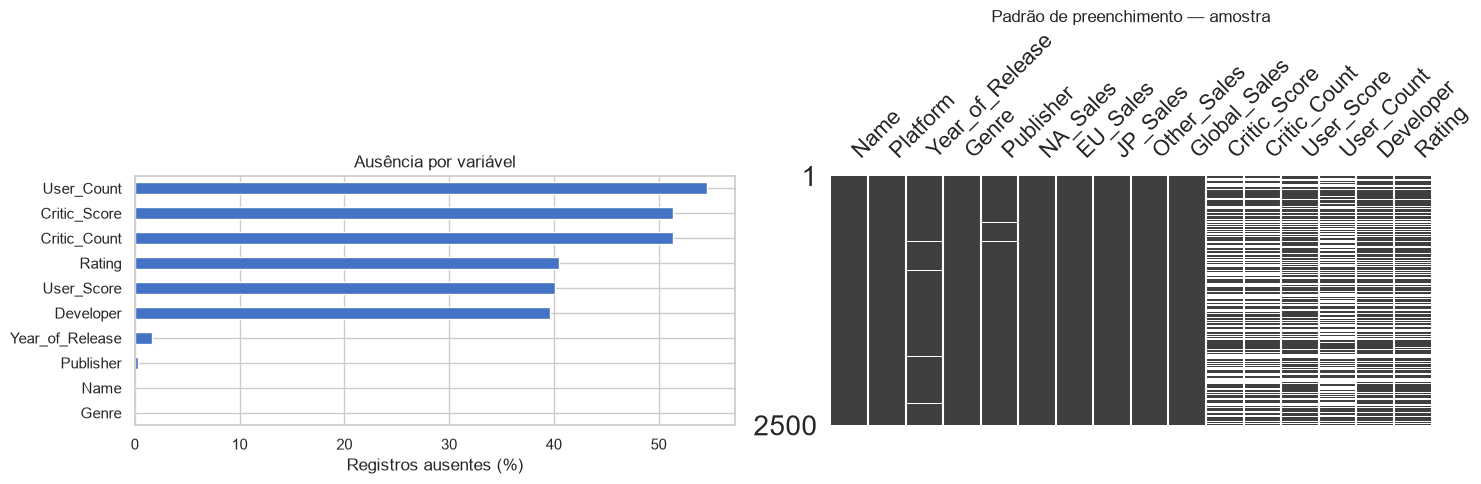

In [4]:
nulos = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "percentual_%": df.isna().mean().mul(100).round(2),
}).sort_values("percentual_%", ascending=False)

quantidade_tbd = df["User_Score"].eq("tbd").sum()
print(f"Registros com User_Score = 'tbd': {quantidade_tbd:,}")
display(nulos)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
nulos.query("ausentes > 0")["percentual_%"].sort_values().plot.barh(ax=eixos[0], color="#4472C4")
eixos[0].set(title="Ausência por variável", xlabel="Registros ausentes (%)", ylabel="")

msno.matrix(df.sample(min(2_500, len(df)), random_state=SEMENTE), ax=eixos[1], sparkline=False)
eixos[1].set_title("Padrão de preenchimento — amostra")
plt.tight_layout()
plt.show()

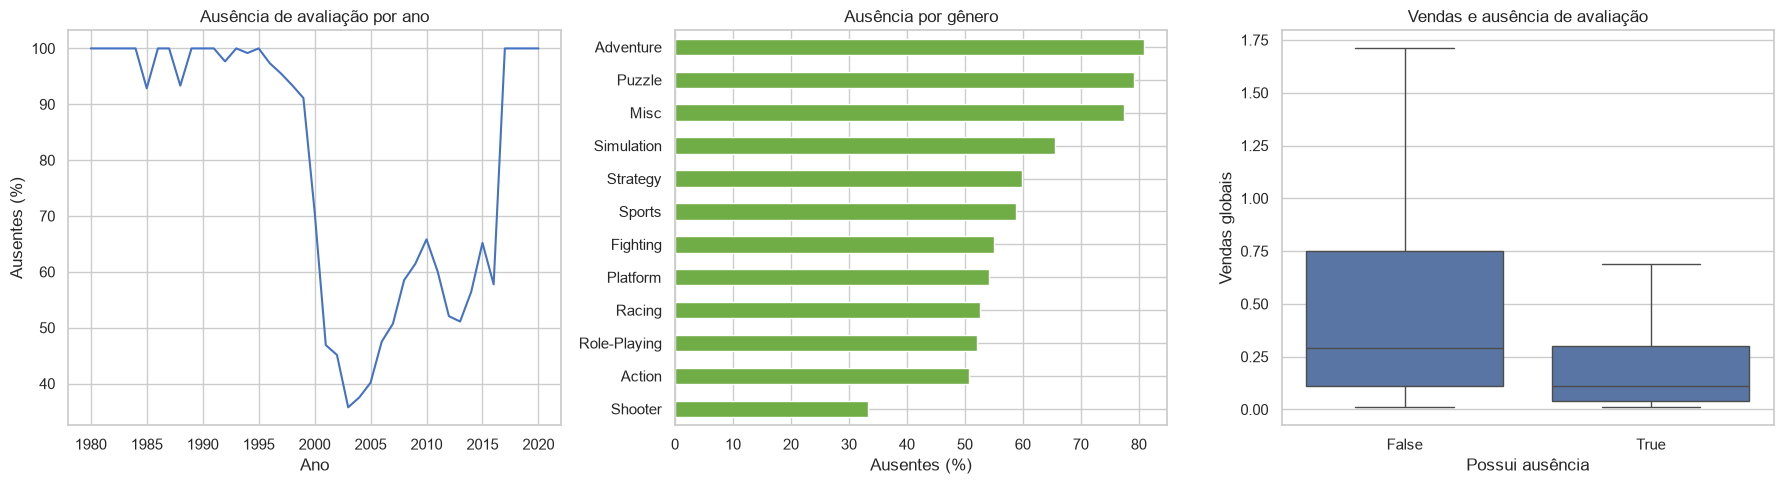

,count,median,mean
possui_ausência,,,
False,6947,0.290,0.773
True,9772,0.110,0.363


In [5]:
# "tbd" significa que a avaliação ainda não foi determinada; não é uma nota.
eda = df.copy()
eda["User_Score"] = pd.to_numeric(eda["User_Score"].replace("tbd", np.nan), errors="coerce")

colunas_avaliacao = [
    "Critic_Score", "Critic_Count", "User_Score",
    "User_Count", "Developer", "Rating",
]
eda["Tem_Ausente_Avaliacao"] = eda[colunas_avaliacao].isna().any(axis=1)

ausencia_por_ano = (
    eda.dropna(subset=["Year_of_Release"])
       .groupby("Year_of_Release")["Tem_Ausente_Avaliacao"]
       .mean().mul(100)
)
ausencia_por_genero = (
    eda.groupby("Genre")["Tem_Ausente_Avaliacao"]
       .mean().mul(100).sort_values()
)

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
eixos[0].plot(ausencia_por_ano.index, ausencia_por_ano.values, color="#4472C4")
eixos[0].set(title="Ausência de avaliação por ano", xlabel="Ano", ylabel="Ausentes (%)")
ausencia_por_genero.plot.barh(ax=eixos[1], color="#70AD47")
eixos[1].set(title="Ausência por gênero", xlabel="Ausentes (%)", ylabel="")
sns.boxplot(data=eda, x="Tem_Ausente_Avaliacao", y=ALVO, showfliers=False, ax=eixos[2])
eixos[2].set(title="Vendas e ausência de avaliação", xlabel="Possui ausência", ylabel="Vendas globais")
plt.tight_layout()
plt.show()

display(
    eda.groupby("Tem_Ausente_Avaliacao")[ALVO]
       .agg(["count", "median", "mean"])
       .rename_axis("possui_ausência")
)

> **Decisão:** converter `tbd` em ausência e preservar os registros incompletos. A ausência varia com ano, gênero e nível de vendas, portanto remover todas as linhas incompletas alteraria a composição da amostra. A imputação será feita dentro do pipeline e ajustada apenas no treino; indicadores de ausência permitirão ao modelo representar parte desse padrão.

### 2.5 Duplicatas semânticas

In [6]:
mesmo_jogo_plataforma = (
    df[df["Name"].notna() & df.duplicated(["Name", "Platform"], keep=False)]
      .sort_values(["Name", "Platform", "Year_of_Release"])
)

print(f"Registros em combinações repetidas de jogo-plataforma: {len(mesmo_jogo_plataforma)}")
display(mesmo_jogo_plataforma)

Registros em combinações repetidas de jogo-plataforma: 8


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
604,Madden NFL 13,PS3,"2,012.000",Sports,Electronic Arts,2.110,0.220,0.000,0.230,2.560,83.000,22.000,5.5,101.000,EA Tiburon,E
16233,Madden NFL 13,PS3,"2,012.000",Sports,Electronic Arts,0.000,0.010,0.000,0.000,0.010,83.000,22.000,5.5,101.000,EA Tiburon,E
5973,Need for Speed: Most Wanted,PC,"2,005.000",Racing,Electronic Arts,0.020,0.230,0.000,0.040,0.290,82.000,19.000,8.5,525.000,Black Box,T
11716,Need for Speed: Most Wanted,PC,"2,012.000",Racing,Electronic Arts,0.000,0.060,0.000,0.020,0.080,82.000,19.000,8.5,525.000,Black Box,T
1591,Need for Speed: Most Wanted,X360,"2,005.000",Racing,Electronic Arts,1.000,0.130,0.020,0.100,1.250,83.000,54.000,8.5,134.000,EA Canada,T
1190,Need for Speed: Most Wanted,X360,"2,012.000",Racing,Electronic Arts,0.620,0.780,0.010,0.150,1.560,83.000,54.000,8.5,134.000,EA Canada,T
1745,Sonic the Hedgehog,PS3,"2,006.000",Platform,Sega,0.410,0.060,0.040,0.660,1.160,43.000,17.000,4.1,176.000,Sonic Team,E10+
4127,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.000,0.480,0.000,0.000,0.480,43.000,17.000,4.1,176.000,Sonic Team,E10+


> **Decisão:** manter essas observações. Repetição da chave simplificada não comprova duplicação integral, e os demais atributos podem registrar lançamentos ou avaliações distintos. Excluir sem uma regra de negócio confirmada destruiria informação legítima.

### 2.6 Distribuição das vendas

A maior parte dos jogos vende pouco, enquanto poucos títulos vendem muito. Os gráficos ajudam a enxergar essa diferença.

,Global_Sales
0.000,0.010
0.250,0.060
0.500,0.170
0.750,0.470
0.900,1.200
0.950,2.040
0.990,5.458
1.000,82.530


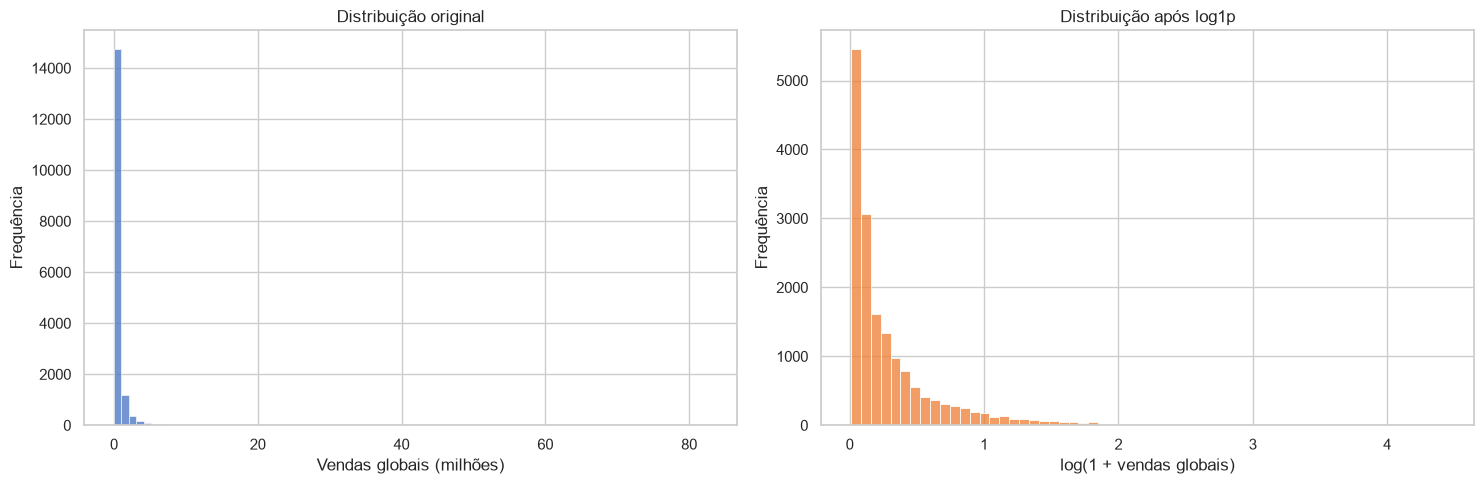

Assimetria original: 17.38
Assimetria após log1p: 2.76


In [7]:
quantis_alvo = eda[ALVO].quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]).to_frame("Global_Sales")
display(quantis_alvo)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(eda[ALVO], bins=80, ax=eixos[0], color="#4472C4")
eixos[0].set(title="Distribuição original", xlabel="Vendas globais (milhões)", ylabel="Frequência")
sns.histplot(np.log1p(eda[ALVO]), bins=60, ax=eixos[1], color="#ED7D31")
eixos[1].set(title="Distribuição após log1p", xlabel="log(1 + vendas globais)", ylabel="Frequência")
plt.tight_layout()
plt.show()

print(f"Assimetria original: {eda[ALVO].skew():.2f}")
print(f"Assimetria após log1p: {np.log1p(eda[ALVO]).skew():.2f}")

#### Leitura visual da cauda de vendas

O histograma mostra a concentração, mas pode esconder a cauda. A distribuição acumulada indica qual parcela dos jogos permanece abaixo de cada nível de vendas, enquanto o boxplot em escala logarítmica mantém os blockbusters visíveis sem comprimir toda a base.

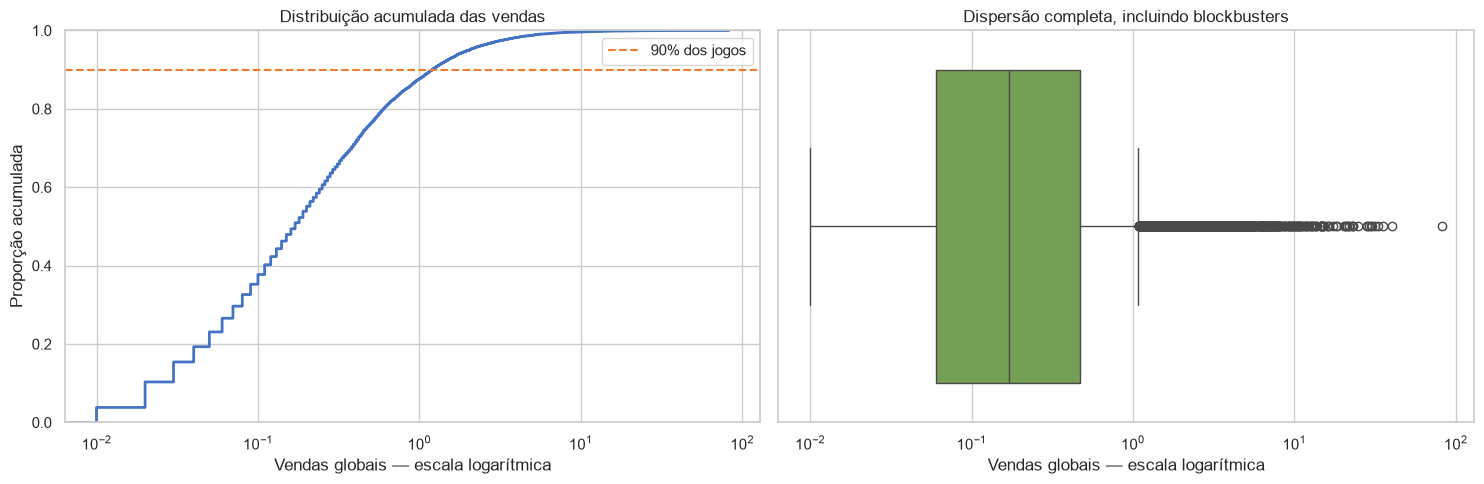

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

sns.ecdfplot(data=eda, x=ALVO, ax=eixos[0], color="#4472C4", linewidth=2)
eixos[0].set_xscale("log")
eixos[0].axhline(0.90, color="#ED7D31", linestyle="--", label="90% dos jogos")
eixos[0].set(
    title="Distribuição acumulada das vendas",
    xlabel="Vendas globais — escala logarítmica",
    ylabel="Proporção acumulada",
)
eixos[0].legend()

sns.boxplot(x=eda[ALVO], ax=eixos[1], color="#70AD47")
eixos[1].set_xscale("log")
eixos[1].set(title="Dispersão completa, incluindo blockbusters", xlabel="Vendas globais — escala logarítmica")

plt.tight_layout()
plt.show()

> **Conclusão:** os blockbusters são casos reais e importantes. Eles foram mantidos, mesmo deixando o problema mais difícil.

### 2.7 Relações com as vendas

Comparamos as vendas com notas, número de avaliações, gênero e plataforma.

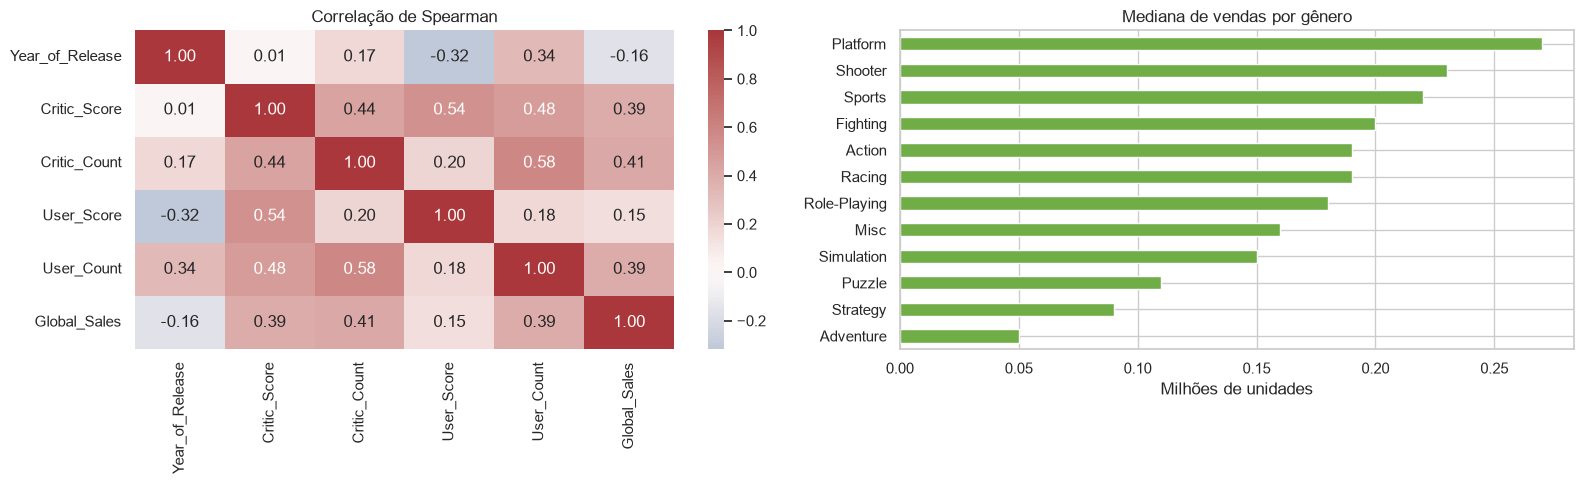

,Global_Sales
Global_Sales,1.000
Critic_Count,0.408
Critic_Score,0.394
User_Count,0.393
User_Score,0.150
Year_of_Release,-0.161


,median,mean,count
Genre,,,
Platform,0.270,0.933,888
Shooter,0.230,0.796,1323
Sports,0.220,0.567,2348
Fighting,0.200,0.527,849
Racing,0.190,0.584,1249
Action,0.190,0.518,3370
Role-Playing,0.180,0.623,1500
Misc,0.160,0.459,1750
Simulation,0.150,0.447,874


In [9]:
numericas_analise = [
    "Year_of_Release", "Critic_Score", "Critic_Count",
    "User_Score", "User_Count", ALVO,
]
correlacoes = eda[numericas_analise].corr(method="spearman")

fig, eixos = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="vlag", center=0, ax=eixos[0])
eixos[0].set_title("Correlação de Spearman")

generos = eda.groupby("Genre")[ALVO].agg(["median", "mean", "count"]).sort_values("median")
generos["median"].plot.barh(ax=eixos[1], color="#70AD47")
eixos[1].set(title="Mediana de vendas por gênero", xlabel="Milhões de unidades", ylabel="")
plt.tight_layout()
plt.show()

display(correlacoes[[ALVO]].sort_values(ALVO, ascending=False))
display(generos.sort_values("median", ascending=False))

#### Como cobertura e avaliações se relacionam com vendas?

Os gráficos usam transparência, amostragem reproduzível e escala logarítmica no alvo. O objetivo é tornar visíveis tanto a concentração de jogos de baixa venda quanto a tendência geral, sem sugerir que correlação implica causalidade.

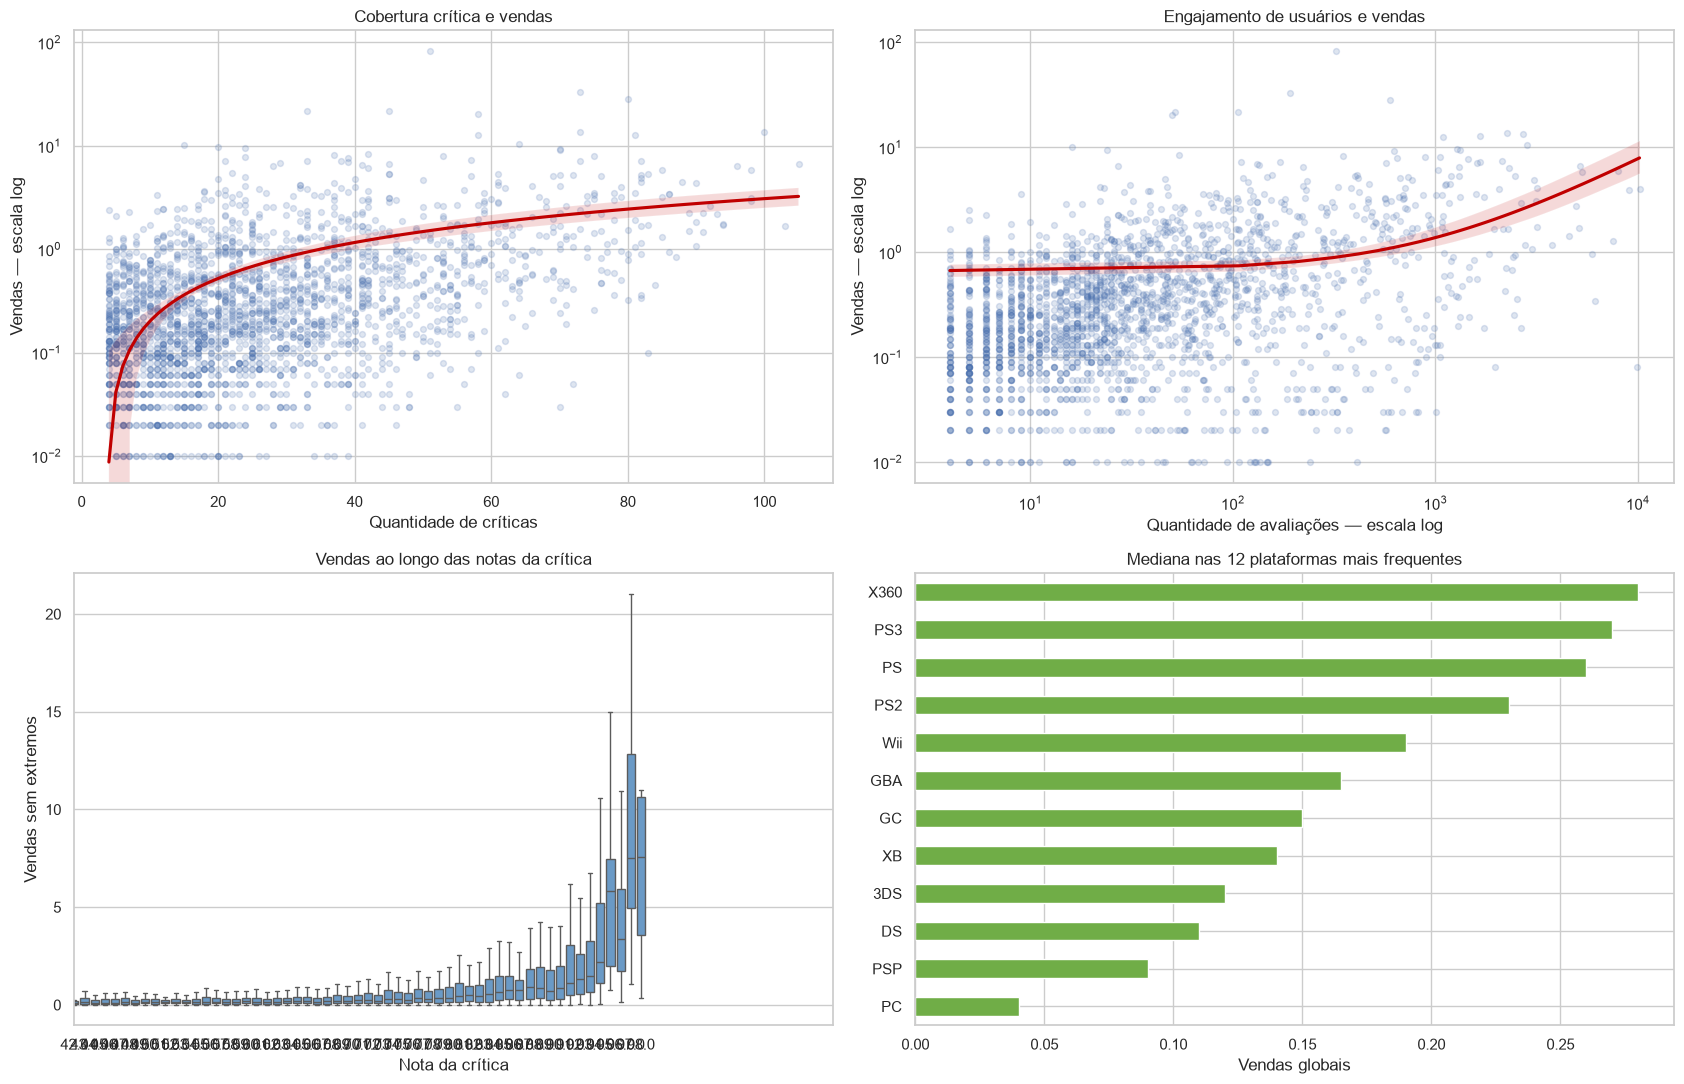

In [10]:
amostra_relacoes = eda.sample(min(5_000, len(eda)), random_state=SEMENTE)
plataformas_principais = eda["Platform"].value_counts().head(12).index
resumo_plataformas = (
    eda[eda["Platform"].isin(plataformas_principais)]
    .groupby("Platform")[ALVO]
    .agg(["median", "mean", "count"])
    .sort_values("median")
)

fig, eixos = plt.subplots(2, 2, figsize=(17, 11))
sns.regplot(
    data=amostra_relacoes, x="Critic_Count", y=ALVO,
    scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "#C00000"},
    ax=eixos[0, 0],
)
eixos[0, 0].set_yscale("log")
eixos[0, 0].set(title="Cobertura crítica e vendas", xlabel="Quantidade de críticas", ylabel="Vendas — escala log")

sns.regplot(
    data=amostra_relacoes, x="User_Count", y=ALVO,
    scatter_kws={"alpha": 0.18, "s": 18}, line_kws={"color": "#C00000"},
    ax=eixos[0, 1],
)
eixos[0, 1].set(xscale="log", yscale="log", title="Engajamento de usuários e vendas", xlabel="Quantidade de avaliações — escala log", ylabel="Vendas — escala log")

sns.boxplot(data=eda, x="Critic_Score", y=ALVO, showfliers=False, ax=eixos[1, 0], color="#5B9BD5")
eixos[1, 0].set_xlim(25, 100)
eixos[1, 0].set(title="Vendas ao longo das notas da crítica", xlabel="Nota da crítica", ylabel="Vendas sem extremos")

resumo_plataformas["median"].plot.barh(ax=eixos[1, 1], color="#70AD47")
eixos[1, 1].set(title="Mediana nas 12 plataformas mais frequentes", xlabel="Vendas globais", ylabel="")

plt.tight_layout()
plt.show()

> **Decisão:** `Critic_Count` será usada na regressão simples porque apresenta associação relevante com o alvo e uma interpretação clara como intensidade de cobertura crítica. A regressão múltipla acrescentará notas, engajamento, ano e categorias para verificar se oferecem informação incremental. Associação não será descrita como causalidade.

## 3) Data Preparation

Nesta etapa os dados são preparados para os modelos.

### 3.1 Escolha das variáveis

As vendas regionais foram retiradas porque sua soma forma Global_Sales. Usá-las seria vazamento de dados.

Name também foi retirado por funcionar como identificador. Foram criadas versões em log das contagens e alguns termos de grau 2 para testar a regressão polinomial.

In [11]:
VENDAS_REGIONAIS = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
NUMERICAS_BASE = ["Year_of_Release", "Critic_Score", "Critic_Count", "User_Score", "User_Count"]
CATEGORICAS_BASE = ["Platform", "Genre", "Rating"]
CATEGORICAS_ESTENDIDAS = CATEGORICAS_BASE + ["Publisher", "Developer"]

dados_modelo = df.copy()
dados_modelo["User_Score"] = pd.to_numeric(
    dados_modelo["User_Score"].replace("tbd", np.nan), errors="coerce"
)

# Logaritmos reduzem a influência de contagens extremamente assimétricas.
dados_modelo["Log_Critic_Count"] = np.log1p(dados_modelo["Critic_Count"])
dados_modelo["Log_User_Count"] = np.log1p(dados_modelo["User_Count"])

# Termos não lineares continuam formando uma regressão linear nos coeficientes.
dados_modelo["Critic_Score_Quadrado"] = dados_modelo["Critic_Score"] ** 2
dados_modelo["User_Score_Quadrado"] = dados_modelo["User_Score"] ** 2
dados_modelo["Interacao_Critica_Usuario"] = (
    dados_modelo["Critic_Score"] * dados_modelo["User_Score"]
)

NUMERICAS_LOG = [
    "Year_of_Release", "Critic_Score", "Log_Critic_Count",
    "User_Score", "Log_User_Count",
]
NUMERICAS_EXPANDIDAS = NUMERICAS_LOG + [
    "Critic_Score_Quadrado", "User_Score_Quadrado", "Interacao_Critica_Usuario",
]

assert not set(VENDAS_REGIONAIS).intersection(NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS)
assert "Name" not in NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS

print("Variáveis regionais excluídas:", VENDAS_REGIONAIS)
print("Identificador excluído: Name")

Variáveis regionais excluídas: ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
Identificador excluído: Name


### 3.2 Treino e teste

A base foi dividida em 80% para treino e 20% para teste. O teste fica separado até a escolha do modelo.

In [12]:
# O teste fica isolado até a escolha do modelo. Todas as comparações usam apenas o treino.
indices_treino, indices_teste = train_test_split(
    dados_modelo.index,
    test_size=0.20,
    random_state=SEMENTE,
)

treino = dados_modelo.loc[indices_treino].copy()
teste = dados_modelo.loc[indices_teste].copy()
y_treino = treino[ALVO]
y_teste = teste[ALVO]

print(f"Treino: {len(treino):,} registros ({len(treino) / len(dados_modelo):.0%})")
print(f"Teste reservado: {len(teste):,} registros ({len(teste) / len(dados_modelo):.0%})")

Treino: 13,375 registros (80%)
Teste reservado: 3,344 registros (20%)


### 3.3 Preparação com pipeline

O pipeline preenche valores ausentes, padroniza números e transforma categorias em colunas numéricas. Tudo é ajustado somente no treino.

In [13]:
def criar_preprocessador(numericas, categoricas):
    # Cria imputação, escala e codificação ajustadas somente dentro de cada treino.
    pipeline_numerico = Pipeline([
        ("imputacao", SimpleImputer(strategy="median", add_indicator=True)),
        ("escala", StandardScaler()),
    ])
    pipeline_categorico = Pipeline([
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ])
    return ColumnTransformer([
        ("numericas", pipeline_numerico, numericas),
        ("categoricas", pipeline_categorico, categoricas),
    ])


def criar_pipeline(regressor, numericas, categoricas):
    # Une pré-processamento e regressão em um único objeto validável.
    return Pipeline([
        ("preprocessamento", criar_preprocessador(numericas, categoricas)),
        ("regressao", regressor),
    ])


cv = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)
metricas_cv = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

> **Decisão:** imputação, escala, agrupamento de categorias raras e codificação permanecem dentro do pipeline. Assim, cada dobra da validação aprende esses parâmetros apenas com sua porção de treino. Categorias novas são ignoradas de forma segura, e `Publisher`/`Developer` não geram uma coluna para cada ocorrência rara.

## 4) Modeling

Começamos com modelos simples e adicionamos variáveis aos poucos.

### 4.1 Modelos utilizados

Comparamos um baseline, uma regressão simples, regressões múltiplas, transformações em log e uma regressão polinomial.

In [14]:
modelos = {}

modelos["Baseline — mediana"] = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("regressao", DummyRegressor(strategy="median")),
])

modelos["Linear simples — Critic_Count"] = Pipeline([
    ("imputacao", SimpleImputer(strategy="median", add_indicator=True)),
    ("regressao", LinearRegression()),
])

modelos["Linear múltipla — base"] = criar_pipeline(
    LinearRegression(), NUMERICAS_BASE, CATEGORICAS_BASE
)
modelos["Linear múltipla — Publisher/Developer"] = criar_pipeline(
    LinearRegression(), NUMERICAS_BASE, CATEGORICAS_ESTENDIDAS
)
modelos["Linear múltipla — contagens em log"] = criar_pipeline(
    LinearRegression(), NUMERICAS_LOG, CATEGORICAS_ESTENDIDAS
)

pipeline_alvo_log = criar_pipeline(
    LinearRegression(), NUMERICAS_LOG, CATEGORICAS_ESTENDIDAS
)
modelos["Linear — alvo em log"] = TransformedTargetRegressor(
    regressor=pipeline_alvo_log,
    func=np.log1p,
    inverse_func=np.expm1,
)


### 4.2 Regressão polinomial

Foram adicionados o quadrado das notas e uma interação entre crítica e usuários. O modelo continua usando OLS, mas consegue representar uma pequena curva.

Não criamos todas as combinações possíveis para não deixar o modelo grande demais.

In [15]:
modelos["Regressão polinomial — grau 2"] = criar_pipeline(
    LinearRegression(),
    NUMERICAS_EXPANDIDAS,
    CATEGORICAS_ESTENDIDAS,
)

print("Termos polinomiais avaliados:")
print("- Critic_Score²")
print("- User_Score²")
print("- Critic_Score × User_Score")


Termos polinomiais avaliados:
- Critic_Score²
- User_Score²
- Critic_Score × User_Score


> **Critério:** a regressão polinomial só será escolhida se a melhora compensar a perda de simplicidade.

### 4.3 Validação cruzada

Usamos cinco divisões do treino. Todos os modelos passam pelas mesmas divisões.

In [16]:
def colunas_do_modelo(nome):
    # Retorna exatamente as colunas exigidas por cada candidato.
    if nome == "Baseline — mediana" or nome == "Linear simples — Critic_Count":
        return ["Critic_Count"]
    if nome == "Linear múltipla — base":
        return NUMERICAS_BASE + CATEGORICAS_BASE
    if nome == "Linear múltipla — Publisher/Developer":
        return NUMERICAS_BASE + CATEGORICAS_ESTENDIDAS
    if "polinomial" in nome.lower():
        return NUMERICAS_EXPANDIDAS + CATEGORICAS_ESTENDIDAS
    return NUMERICAS_LOG + CATEGORICAS_ESTENDIDAS


resultados = []
for nome, modelo in modelos.items():
    colunas = colunas_do_modelo(nome)
    pontuacoes = cross_validate(
        modelo,
        treino[colunas],
        y_treino,
        scoring=metricas_cv,
        cv=cv,
        n_jobs=1,
        return_train_score=True,
    )
    resultados.append({
        "modelo": nome,
        "RMSE_cv": -pontuacoes["test_RMSE"].mean(),
        "RMSE_cv_dp": pontuacoes["test_RMSE"].std(),
        "RMSE_treino": -pontuacoes["train_RMSE"].mean(),
        "MAE_cv": -pontuacoes["test_MAE"].mean(),
        "R2_cv": pontuacoes["test_R2"].mean(),
    })

comparacao_modelos = pd.DataFrame(resultados).sort_values("RMSE_cv").reset_index(drop=True)
display(comparacao_modelos.round(4))

,modelo,RMSE_cv,RMSE_cv_dp,RMSE_treino,MAE_cv,R2_cv
0,Regressão polinomial — grau 2,1.201,0.065,1.186,0.497,0.264
1,Linear múltipla — contagens em log,1.207,0.061,1.192,0.500,0.257
2,Linear múltipla — Publisher/Developer,1.212,0.069,1.193,0.487,0.251
3,Linear — alvo em log,1.212,0.061,1.206,0.388,0.250
4,Linear múltipla — base,1.266,0.069,1.255,0.503,0.183
5,Linear simples — Critic_Count,1.343,0.066,1.345,0.529,0.079
6,Baseline — mediana,1.444,0.060,1.445,0.457,-0.065


#### Ganho e estabilidade dos modelos

As barras com intervalo mostram a média do RMSE entre as cinco dobras e um desvio-padrão. O segundo painel compara treino e validação: uma distância grande seria evidência de sobreajuste.

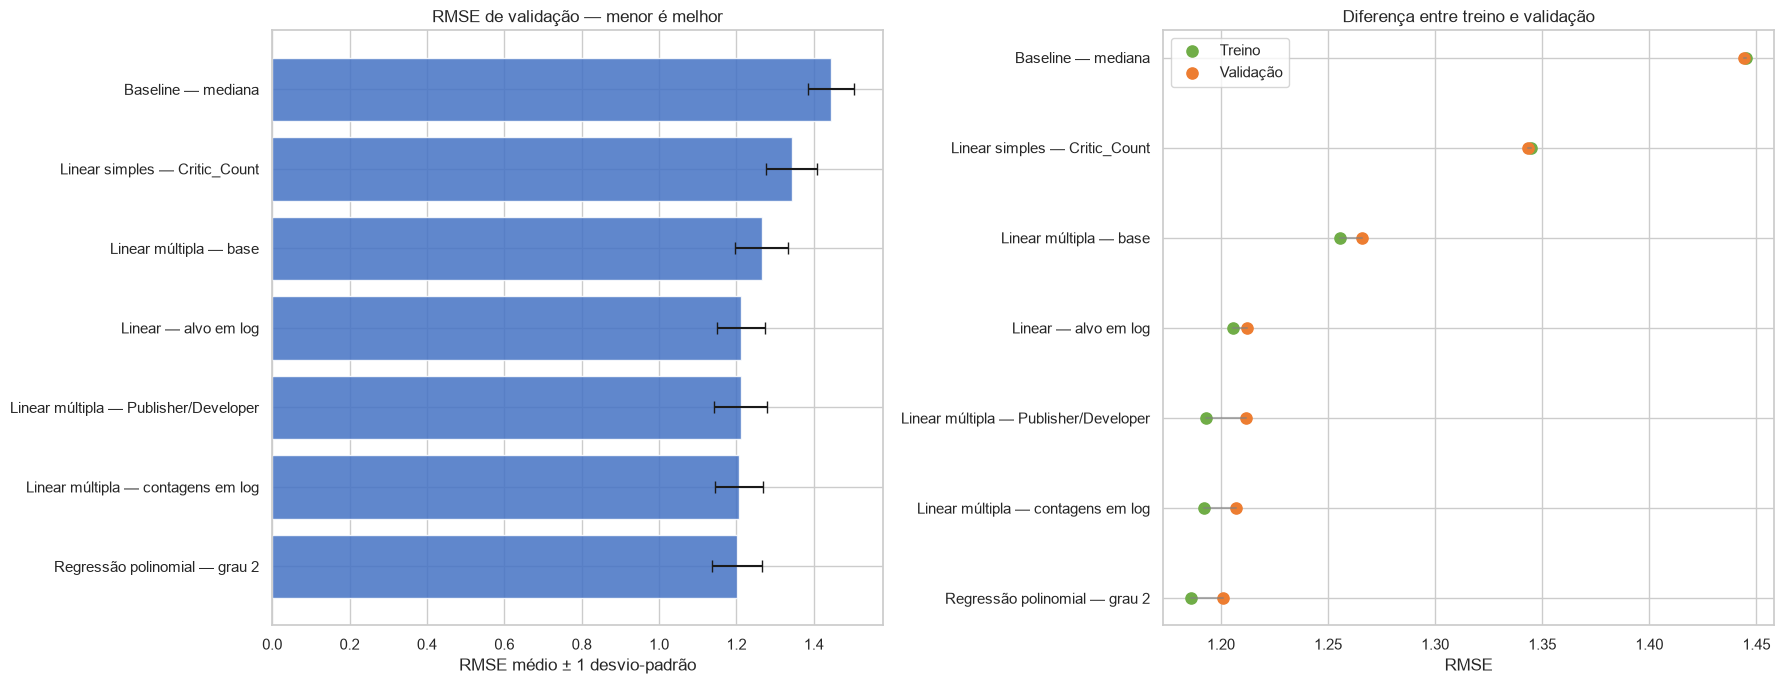

In [17]:
ordem_grafico = comparacao_modelos.sort_values("RMSE_cv", ascending=True)

fig, eixos = plt.subplots(1, 2, figsize=(18, 7))
eixos[0].barh(
    ordem_grafico["modelo"], ordem_grafico["RMSE_cv"],
    xerr=ordem_grafico["RMSE_cv_dp"], color="#4472C4", alpha=0.85, capsize=4,
)
eixos[0].set(title="RMSE de validação — menor é melhor", xlabel="RMSE médio ± 1 desvio-padrão", ylabel="")

posicoes = np.arange(len(ordem_grafico))
eixos[1].scatter(ordem_grafico["RMSE_treino"], posicoes, label="Treino", color="#70AD47", s=65)
eixos[1].scatter(ordem_grafico["RMSE_cv"], posicoes, label="Validação", color="#ED7D31", s=65)
for posicao, (_, linha) in zip(posicoes, ordem_grafico.iterrows()):
    eixos[1].plot([linha["RMSE_treino"], linha["RMSE_cv"]], [posicao, posicao], color="gray", alpha=0.6)
eixos[1].set_yticks(posicoes, ordem_grafico["modelo"])
eixos[1].set(title="Diferença entre treino e validação", xlabel="RMSE", ylabel="")
eixos[1].legend()

plt.tight_layout()
plt.show()

In [18]:
melhor_nome = comparacao_modelos.loc[0, "modelo"]
segundo_rmse = comparacao_modelos.loc[1, "RMSE_cv"]
melhor_rmse = comparacao_modelos.loc[0, "RMSE_cv"]
ganho_relativo = (segundo_rmse - melhor_rmse) / segundo_rmse

# Um ganho inferior a 0,5% não compensa termos expandidos se houver alternativa mais simples.
if "polinomial" in melhor_nome.lower() and ganho_relativo < 0.005:
    candidatos_simples = comparacao_modelos[~comparacao_modelos["modelo"].str.contains("polinomial", case=False)]
    melhor_nome = candidatos_simples.iloc[0]["modelo"]
    criterio_complexidade = "regressão polinomial rejeitada: ganho inferior a 0,5%"
else:
    criterio_complexidade = "melhor RMSE mantido; eventual curvatura justificou a complexidade"

modelo_final = clone(modelos[melhor_nome])
colunas_finais = colunas_do_modelo(melhor_nome)

print(f"Modelo selecionado: {melhor_nome}")
print(f"Critério de parcimônia: {criterio_complexidade}")

Modelo selecionado: Linear múltipla — contagens em log
Critério de parcimônia: regressão polinomial rejeitada: ganho inferior a 0,5%


> **Escolha:** a regressão polinomial melhorou muito pouco. Como essa diferença foi menor que a variação entre as dobras, escolhemos a regressão múltipla com contagens em log.

## 5) Evaluation

Agora avaliamos o modelo escolhido no teste reservado.

### 5.1 Resultado no teste

O modelo é treinado com todo o conjunto de treino e aplicado ao teste.

In [19]:
modelo_final.fit(treino[colunas_finais], y_treino)
previsao_bruta = modelo_final.predict(teste[colunas_finais])
previsao_nao_negativa = np.clip(previsao_bruta, 0, None)

def calcular_metricas(y_real, y_previsto):
    # Calcula as três métricas adotadas no projeto.
    return {
        "RMSE": mean_squared_error(y_real, y_previsto) ** 0.5,
        "MAE": mean_absolute_error(y_real, y_previsto),
        "R2": r2_score(y_real, y_previsto),
    }


metricas_teste = pd.DataFrame([
    {"previsão": "bruta", **calcular_metricas(y_teste, previsao_bruta)},
    {"previsão": "limitada a zero", **calcular_metricas(y_teste, previsao_nao_negativa)},
])

quantidade_negativas = int((previsao_bruta < 0).sum())
percentual_negativas = quantidade_negativas / len(previsao_bruta) * 100

print(f"Modelo final: {melhor_nome}")
print(f"Previsões negativas antes do corte: {quantidade_negativas:,} ({percentual_negativas:.2f}%)")
display(metricas_teste.round(4))

Modelo final: Linear múltipla — contagens em log
Previsões negativas antes do corte: 539 (16.12%)


,previsão,RMSE,MAE,R2
0,bruta,1.797,0.530,0.218
1,limitada a zero,1.790,0.494,0.224


#### Onde a previsão acompanha os valores reais?

A escala logarítmica permite avaliar a região em que está a maioria dos jogos. A curva por decis mostra se o modelo acompanha o nível médio de vendas ou comprime excessivamente os extremos.

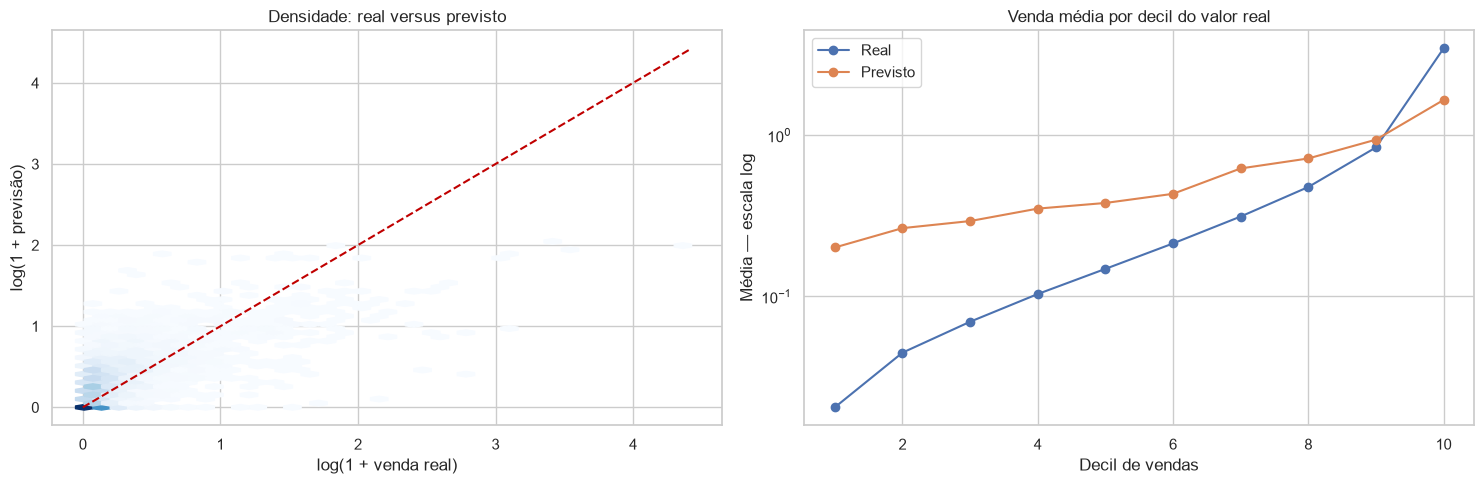

In [20]:
comparacao_decis = pd.DataFrame({"real": y_teste, "previsto": previsao_nao_negativa})
comparacao_decis["decil_real"] = pd.qcut(comparacao_decis["real"], 10, duplicates="drop")
resumo_decis = comparacao_decis.groupby("decil_real", observed=True).agg(
    venda_real=("real", "mean"),
    venda_prevista=("previsto", "mean"),
    registros=("real", "size"),
).reset_index(drop=True)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
eixos[0].hexbin(
    np.log1p(y_teste), np.log1p(previsao_nao_negativa),
    gridsize=35, mincnt=1, cmap="Blues",
)
limite_log = max(np.log1p(y_teste).max(), np.log1p(previsao_nao_negativa).max())
eixos[0].plot([0, limite_log], [0, limite_log], "--", color="#C00000")
eixos[0].set(title="Densidade: real versus previsto", xlabel="log(1 + venda real)", ylabel="log(1 + previsão)")

eixos[1].plot(resumo_decis.index + 1, resumo_decis["venda_real"], marker="o", label="Real")
eixos[1].plot(resumo_decis.index + 1, resumo_decis["venda_prevista"], marker="o", label="Previsto")
eixos[1].set_yscale("log")
eixos[1].set(title="Venda média por decil do valor real", xlabel="Decil de vendas", ylabel="Média — escala log")
eixos[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Análise dos erros

O resíduo é a diferença entre a venda real e a previsão. Os maiores resíduos indicam onde o modelo teve mais dificuldade.

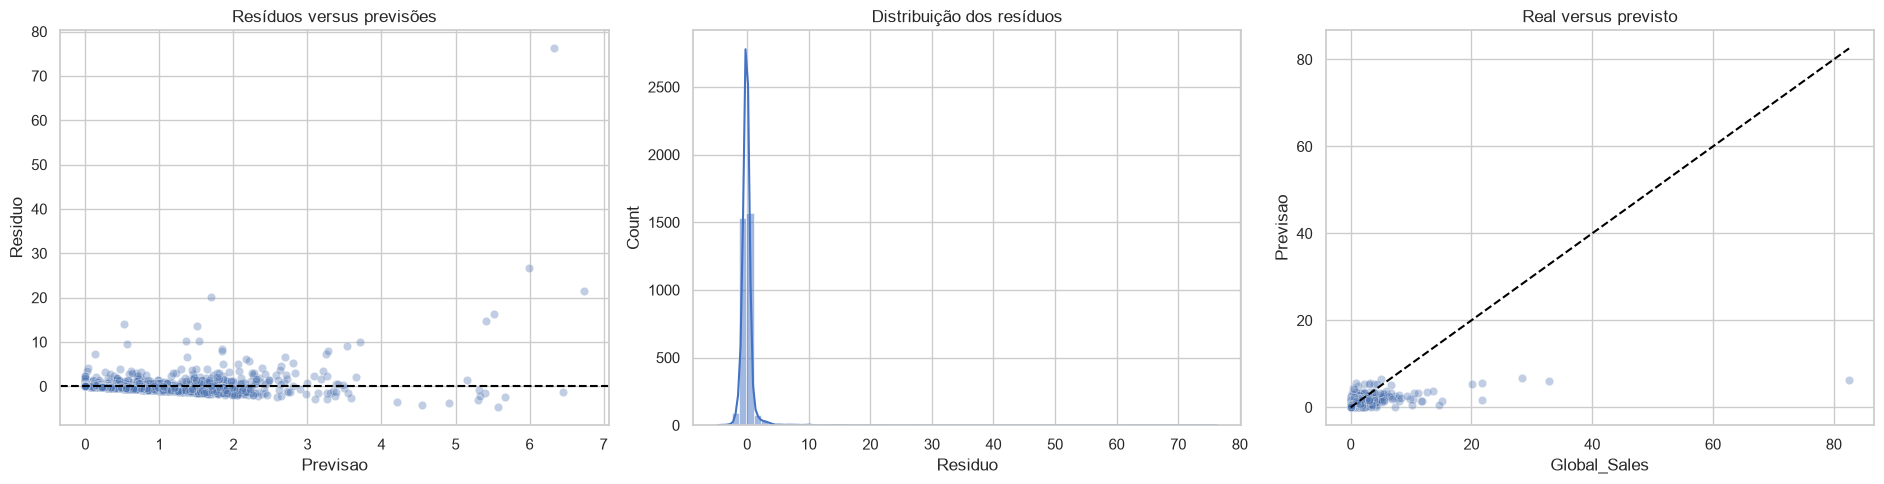

,Name,Platform,Genre,Global_Sales,Previsao,Residuo,Erro_Absoluto
0,Wii Sports,Wii,Sports,82.530,6.328,76.202,76.202
3,Wii Sports Resort,Wii,Sports,32.770,5.987,26.783,26.783
8,New Super Mario Bros. Wii,Wii,Platform,28.320,6.732,21.588,21.588
14,Kinect Adventures!,X360,Misc,21.810,1.691,20.119,20.119
15,Wii Fit Plus,Wii,Sports,21.790,5.513,16.277,16.277
19,Brain Age: Train Your Brain in Minutes a Day,DS,Misc,20.150,5.416,14.734,14.734
31,Call of Duty: Black Ops 3,PS4,Shooter,14.630,0.516,14.114,14.114
27,Pokemon Black/Pokemon White,DS,Role-Playing,15.140,1.509,13.631,13.631
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,Role-Playing,11.680,1.356,10.324,10.324
46,Pokemon HeartGold/Pokemon SoulSilver,DS,Action,11.770,1.532,10.238,10.238


In [21]:
avaliacao = teste[["Name", "Platform", "Genre", ALVO]].copy()
avaliacao["Previsao"] = previsao_nao_negativa
avaliacao["Residuo"] = avaliacao[ALVO] - avaliacao["Previsao"]
avaliacao["Erro_Absoluto"] = avaliacao["Residuo"].abs()
avaliacao["Faixa_Vendas"] = pd.cut(
    avaliacao[ALVO],
    bins=[-np.inf, 0.1, 0.5, 1, 5, np.inf],
    labels=["Até 0,1", "0,1–0,5", "0,5–1", "1–5", "Acima de 5"],
)

fig, eixos = plt.subplots(1, 3, figsize=(19, 5))
sns.scatterplot(data=avaliacao, x="Previsao", y="Residuo", alpha=0.35, ax=eixos[0])
eixos[0].axhline(0, color="black", linestyle="--")
eixos[0].set_title("Resíduos versus previsões")
sns.histplot(avaliacao["Residuo"], bins=70, kde=True, ax=eixos[1], color="#4472C4")
eixos[1].set_title("Distribuição dos resíduos")
sns.scatterplot(data=avaliacao, x=ALVO, y="Previsao", alpha=0.35, ax=eixos[2])
limite = max(avaliacao[ALVO].max(), avaliacao["Previsao"].max())
eixos[2].plot([0, limite], [0, limite], "--", color="black")
eixos[2].set_title("Real versus previsto")
plt.tight_layout()
plt.show()

display(
    avaliacao.nlargest(10, "Erro_Absoluto")
    [["Name", "Platform", "Genre", ALVO, "Previsao", "Residuo", "Erro_Absoluto"]]
)

### 5.3 Erro por grupo

Também verificamos o erro por faixa de vendas, gênero e plataforma.

In [22]:
def resumo_por_grupo(dados, coluna, minimo=20):
    # Resume erro por segmento e omite grupos pequenos e instáveis.
    resumo = dados.groupby(coluna, observed=True).agg(
        registros=(ALVO, "size"),
        venda_media=(ALVO, "mean"),
        MAE=("Erro_Absoluto", "mean"),
        vies=("Residuo", "mean"),
    )
    return resumo.query("registros >= @minimo").sort_values("MAE", ascending=False)


print("Desempenho por faixa de vendas")
display(resumo_por_grupo(avaliacao, "Faixa_Vendas", minimo=1))
print("Desempenho por gênero")
display(resumo_por_grupo(avaliacao, "Genre"))
print("Desempenho nas plataformas com pelo menos 20 registros de teste")
display(resumo_por_grupo(avaliacao, "Platform"))

Desempenho por faixa de vendas


,registros,venda_media,MAE,vies
Faixa_Vendas,,,,
Acima de 5,46,11.332,8.623,8.563
1–5,351,2.010,0.933,0.585
"0,5–1",371,0.713,0.430,-0.136
"0,1–0,5",1354,0.251,0.346,-0.248
"Até 0,1",1222,0.050,0.246,-0.216


Desempenho por gênero


,registros,venda_media,MAE,vies
Genre,,,,
Shooter,258,0.853,0.733,-0.059
Platform,170,0.851,0.720,-0.088
Sports,465,0.752,0.597,0.186
Role-Playing,306,0.633,0.575,-0.039
Misc,324,0.565,0.514,0.070
Racing,243,0.555,0.467,-0.042
Puzzle,116,0.411,0.464,-0.212
Simulation,199,0.418,0.430,-0.066
Action,703,0.506,0.409,-0.051


Desempenho nas plataformas com pelo menos 20 registros de teste


,registros,venda_media,MAE,vies
Platform,,,,
Wii,268,1.081,0.961,0.415
WiiU,26,0.621,0.740,-0.549
PS4,82,0.778,0.647,-0.077
SNES,55,0.544,0.639,-0.407
PC,176,0.388,0.626,-0.249
X360,252,0.773,0.610,0.015
N64,75,0.686,0.546,0.041
GBA,164,0.377,0.484,-0.124
3DS,119,0.450,0.467,0.037


#### Mapa de erro por gênero e faixa de vendas

O mapa cruza duas dimensões que isoladamente podem esconder problemas. Células vazias ou com menos de cinco jogos são omitidas para evitar conclusões baseadas em amostras frágeis.

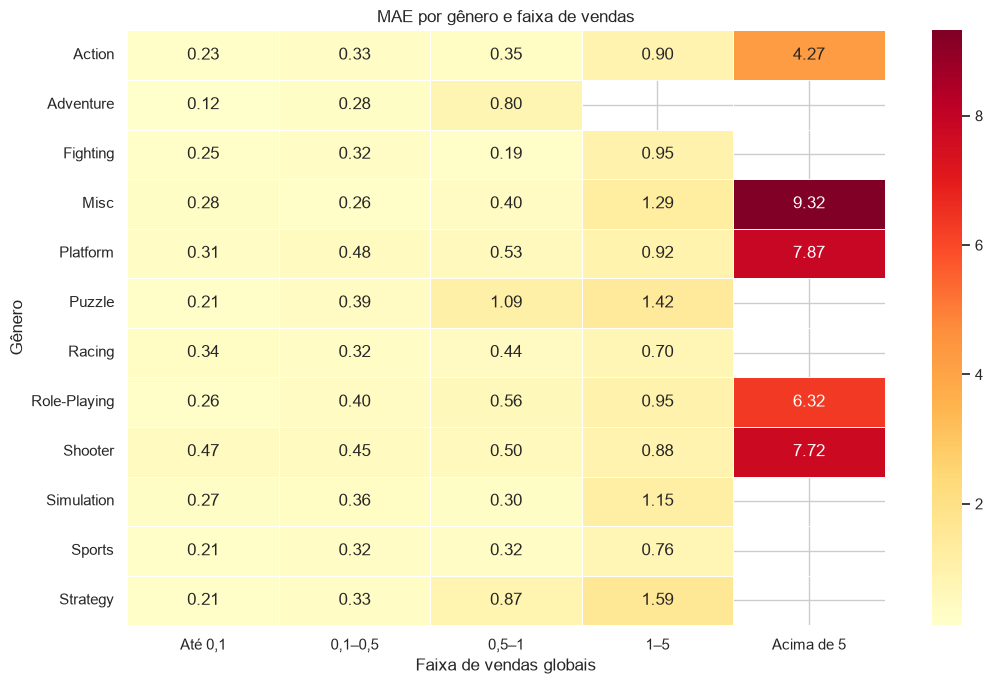

In [23]:
erro_cruzado = (
    avaliacao.groupby(["Genre", "Faixa_Vendas"], observed=True)
    .agg(MAE=("Erro_Absoluto", "mean"), registros=(ALVO, "size"))
    .reset_index()
)
erro_cruzado.loc[erro_cruzado["registros"] < 5, "MAE"] = np.nan
mapa_erro = erro_cruzado.pivot(index="Genre", columns="Faixa_Vendas", values="MAE")

plt.figure(figsize=(11, 7))
sns.heatmap(mapa_erro, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("MAE por gênero e faixa de vendas")
plt.xlabel("Faixa de vendas globais")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()

> **Conclusão:** os maiores erros aparecem principalmente nos blockbusters. O modelo funciona melhor para jogos com vendas mais comuns.

### 5.4 OLS com statsmodels

LinearRegression já utiliza mínimos quadrados ordinários. Também ajustamos um modelo menor com statsmodels para visualizar coeficientes, p-valores e R² ajustado.

Foram usadas somente as variáveis numéricas. O alvo foi transformado com log1p para reduzir o peso dos valores extremos.

In [24]:
COLUNAS_OLS = [
    "Year_of_Release",
    "Critic_Score",
    "Log_Critic_Count",
    "User_Score",
    "Log_User_Count",
]

# Imputação e escala aprendidas somente no treino
imputador_ols = SimpleImputer(strategy="median")
escalador_ols = StandardScaler()

X_ols_treino = imputador_ols.fit_transform(treino[COLUNAS_OLS])
X_ols_treino = escalador_ols.fit_transform(X_ols_treino)
X_ols_treino = sm.add_constant(X_ols_treino)

modelo_ols = sm.OLS(np.log1p(y_treino), X_ols_treino).fit()
tabela_ols = pd.DataFrame({
    "variável": ["constante"] + COLUNAS_OLS,
    "coeficiente": modelo_ols.params,
    "p_valor": modelo_ols.pvalues,
})

print(f"R² ajustado no treino: {modelo_ols.rsquared_adj:.4f}")
display(tabela_ols.round(4))

R² ajustado no treino: 0.2242


,variável,coeficiente,p_valor
const,constante,0.303,0.000
x1,Year_of_Release,-0.088,0.000
x2,Critic_Score,0.059,0.000
x3,Log_Critic_Count,0.036,0.000
x4,User_Score,-0.035,0.000
x5,Log_User_Count,0.132,0.000


#### Gráficos dos resíduos

No primeiro gráfico buscamos pontos espalhados sem um desenho claro. No gráfico Q–Q buscamos pontos próximos da linha. Grandes desvios indicam que os pressupostos não são atendidos perfeitamente.

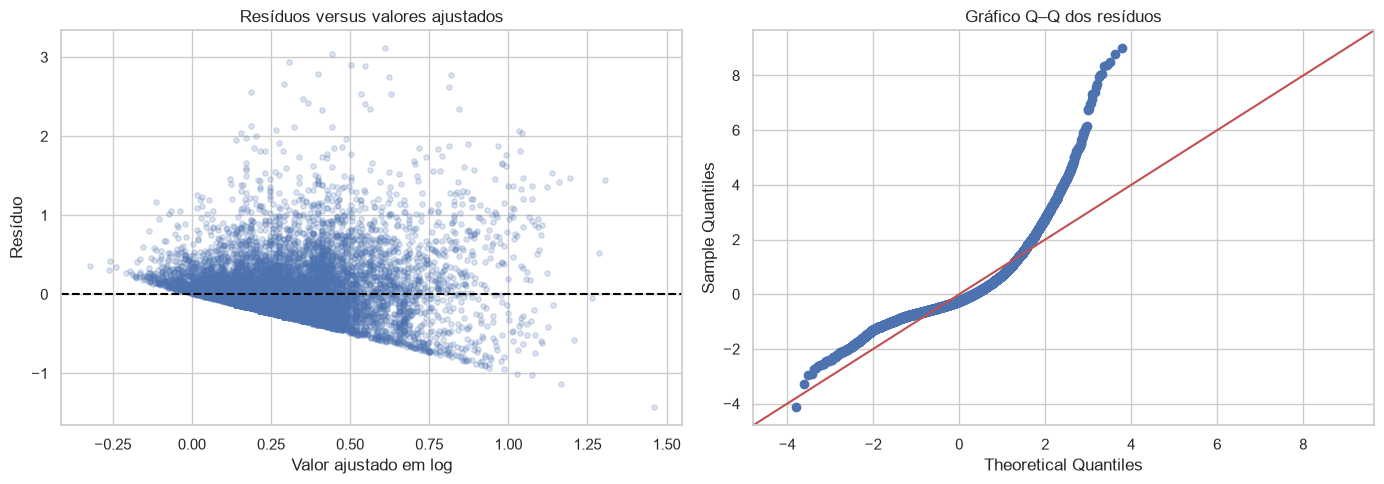

Métricas do OLS reduzido no teste:


,RMSE,MAE,R2
0,1.979,0.487,0.051


RESUMO_OLS={"r2_ajustado_log": 0.2242, "rmse_teste": 1.9789, "mae_teste": 0.4867, "r2_teste": 0.0514}


In [25]:
X_ols_teste = imputador_ols.transform(teste[COLUNAS_OLS])
X_ols_teste = escalador_ols.transform(X_ols_teste)
X_ols_teste = sm.add_constant(X_ols_teste)

previsao_ols = np.clip(np.expm1(modelo_ols.predict(X_ols_teste)), 0, None)
metricas_ols = calcular_metricas(y_teste, previsao_ols)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
eixos[0].scatter(modelo_ols.fittedvalues, modelo_ols.resid, alpha=0.2, s=15)
eixos[0].axhline(0, color="black", linestyle="--")
eixos[0].set(title="Resíduos versus valores ajustados", xlabel="Valor ajustado em log", ylabel="Resíduo")
sm.qqplot(modelo_ols.resid, line="45", fit=True, ax=eixos[1])
eixos[1].set_title("Gráfico Q–Q dos resíduos")
plt.tight_layout()
plt.show()

print("Métricas do OLS reduzido no teste:")
display(pd.DataFrame([metricas_ols]).round(4))
resumo_ols = {
    "r2_ajustado_log": round(float(modelo_ols.rsquared_adj), 4),
    "rmse_teste": round(float(metricas_ols["RMSE"]), 4),
    "mae_teste": round(float(metricas_ols["MAE"]), 4),
    "r2_teste": round(float(metricas_ols["R2"]), 4),
}
print("RESUMO_OLS=" + json.dumps(resumo_ols, ensure_ascii=False))

> **Leitura:** os resíduos não seguem perfeitamente os pressupostos do OLS. Por isso, coeficientes e p-valores servem apenas como apoio e não provam causa e efeito.

## 6) Conclusão

O modelo pode ajudar a comparar jogos e encontrar padrões. Ele não deve ser usado sozinho para decidir investimentos, porque a base não possui orçamento, marketing e força da franquia.

In [26]:
linha_cv = comparacao_modelos.set_index("modelo").loc[melhor_nome]
linha_teste = metricas_teste.set_index("previsão").loc["limitada a zero"]

resumo_final = {
    "modelo": melhor_nome,
    "rmse_cv": round(float(linha_cv["RMSE_cv"]), 4),
    "rmse_cv_dp": round(float(linha_cv["RMSE_cv_dp"]), 4),
    "mae_cv": round(float(linha_cv["MAE_cv"]), 4),
    "r2_cv": round(float(linha_cv["R2_cv"]), 4),
    "rmse_teste": round(float(linha_teste["RMSE"]), 4),
    "mae_teste": round(float(linha_teste["MAE"]), 4),
    "r2_teste": round(float(linha_teste["R2"]), 4),
    "previsoes_negativas": quantidade_negativas,
    "percentual_negativas": round(float(percentual_negativas), 2),
}

print("RESUMO_FINAL=" + json.dumps(resumo_final, ensure_ascii=False))

RESUMO_FINAL={"modelo": "Linear múltipla — contagens em log", "rmse_cv": 1.2068, "rmse_cv_dp": 0.0614, "mae_cv": 0.5003, "r2_cv": 0.2565, "rmse_teste": 1.79, "mae_teste": 0.4945, "r2_teste": 0.2238, "previsoes_negativas": 539, "percentual_negativas": 16.12}


### Resultado final

A regressão linear encontrou alguns padrões, mas explicou apenas uma parte das vendas. Os maiores erros ocorreram nos jogos que venderam muito acima da maioria.

A regressão polinomial foi testada, mas sua melhora foi pequena. Por isso, o modelo final continuou sendo uma regressão múltipla por OLS com transformação em log nas contagens.